In [1]:
#IMPORTING LIBRARIES
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler,RobustScaler
from scipy.stats import zscore

import warnings
warnings.filterwarnings("ignore")

In [2]:
print("Week - 01")
#LOADING THE DATASET

df = pd.read_csv("//kaggle/input/fraud-detection/fraudTrain.csv")
print("\nFirst five rows:\n")
print(df.head())
print("\nLast five rows :\n")
print(df.tail())
print("\nColumn names :\n")
print(df.columns)
print("\nnumber of rows and columns:\n")
print(df.shape)
print("\nInfo :")
print(df.info())

Week - 01

First five rows:

   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44      630423337322   
2           2   2019-01-01 00:00:51    38859492057661   
3           3   2019-01-01 00:01:16  3534093764340240   
4           4   2019-01-01 00:03:06   375534208663984   

                             merchant       category     amt      first  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie   
2                fraud_Lind-Buckridge  entertainment  220.11     Edward   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00     Jeremy   
4                 fraud_Keeling-Crist       misc_pos   41.96      Tyler   

      last gender                        street  ...      lat      long  \
0    Banks      F                561 Perry Cove  ...  36.0788  -81.1781   
1     Gill      F  43039 Ri

In [3]:
print("Week - 02")
#KNOWING THE DATASET

print("\nData types :\n")
print(df.dtypes)
print("\n")
print("Statistical Summary :\n",df.describe())

np.random.seed(42)
df.loc[np.random.choice(df.index, 2000, replace=False), 'amt'] = np.nan
df.loc[np.random.choice(df.index, 1500, replace=False), 'city_pop'] = np.nan
df.loc[np.random.choice(df.index, 1000, replace=False), 'merchant'] = np.nan
df.loc[np.random.choice(df.index, 1000, replace=False), 'job'] = np.nan
missing_report = df.isnull().sum().to_frame(name="Missing_Count")
missing_report["Missing_%"] = (missing_report["Missing_Count"] / len(df)) * 100

print("\nMissing Value Report:\n")
print(missing_report.sort_values(by="Missing_%", ascending=False))

def data_quality_report(data):
    report = pd.DataFrame({
        "Data_Type": data.dtypes,
        "Missing_Values": data.isnull().sum(),
        "Missing_%": (data.isnull().sum() / len(data)) * 100,
        "Unique_Values": data.nunique()
    })
    return report

dq_report = data_quality_report(df)

print("\nData Quality Report:\n")
print(dq_report)


Week - 02

Data types :

Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object


Statistical Summary :
          Unnamed: 0        cc_num           amt           zip           lat  \
count  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06   
mean   6.483370e+05

Week - 03
Dataset Shape: (1296675, 22)

Missing Values Before Imputation:

merchant    1000
amt         2000
city_pop    1500
job         1000
dtype: int64


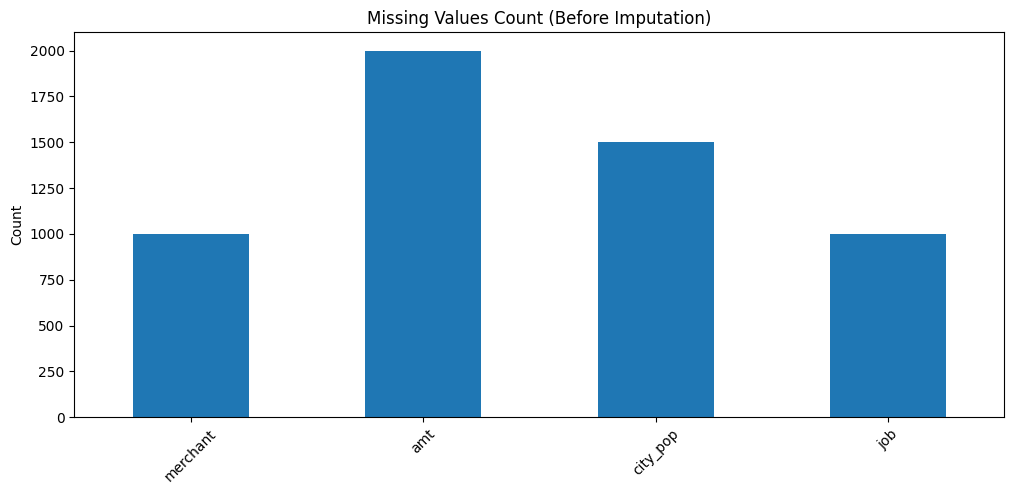


Missing Values After Imputation: 0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

Outlier Detection using IQR
Lower Bound: -100.415
Upper Bound: 193.145
Number of Outliers: 67386


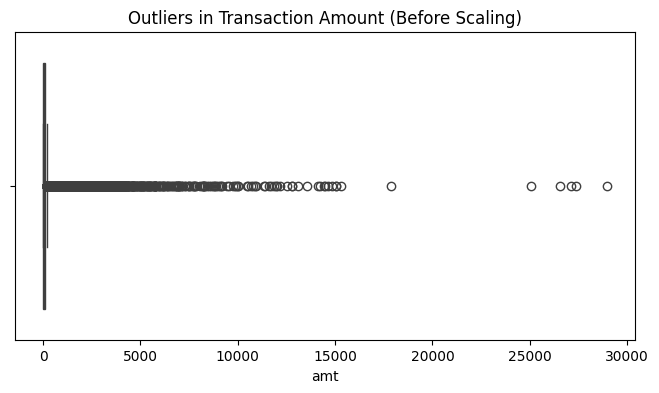

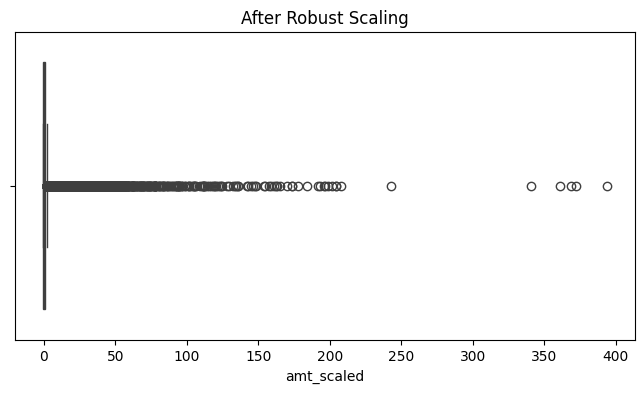

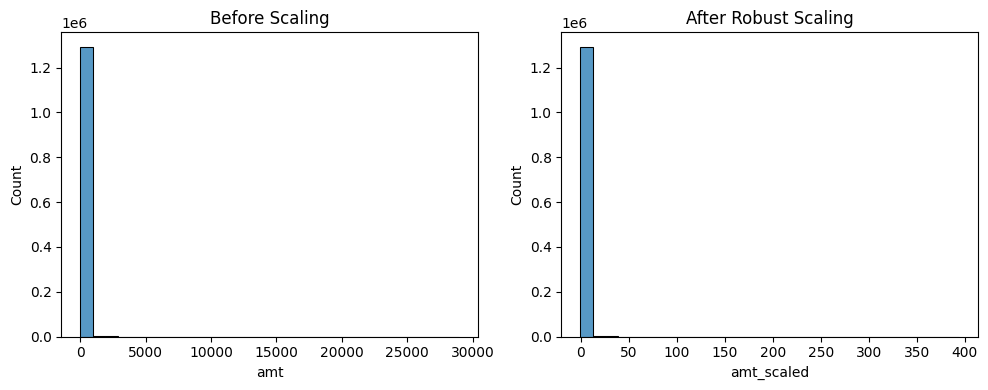

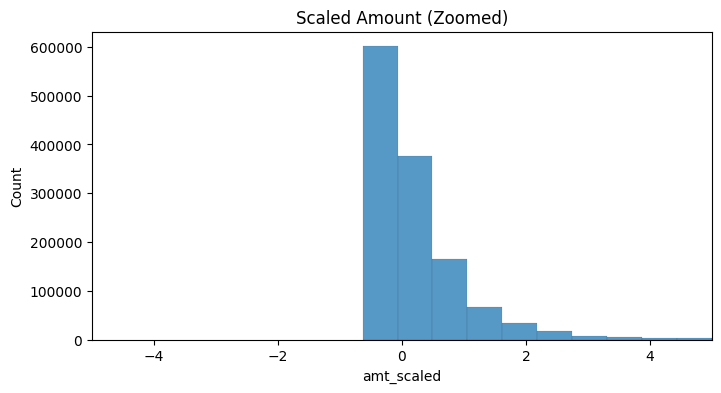

In [4]:
print("Week - 03")
#THE CLEANING SPRINT

df = df.drop(columns=['Unnamed: 0'], errors='ignore')
print("Dataset Shape:", df.shape)
missing_counts = df.isnull().sum()

print("\nMissing Values Before Imputation:\n")
print(missing_counts[missing_counts > 0])

if missing_counts.sum() > 0:
    plt.figure(figsize=(12,5))
    missing_counts[missing_counts > 0].plot(kind='bar')
    plt.title("Missing Values Count (Before Imputation)")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].value_counts().idxmax())

print("\nMissing Values After Imputation:",df.isnull().sum().sum())
missing_counts1 = df.isnull().sum().sum()
print(df.isnull().sum())

if 'amt' in df.columns:   
    Q1 = df['amt'].quantile(0.25)
    Q3 = df['amt'].quantile(0.75)
    IQR = Q3 - Q1    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR    
    outliers = df[(df['amt'] < lower) | (df['amt'] > upper)]    
    print("\nOutlier Detection using IQR")
    print("Lower Bound:", lower)
    print("Upper Bound:", upper)
    print("Number of Outliers:", outliers.shape[0])
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df['amt'])
    plt.title("Outliers in Transaction Amount (Before Scaling)")
    plt.show()

print("\n\n")

if 'amt' in df.columns:   
    scaler = RobustScaler()
    df['amt_scaled'] = scaler.fit_transform(df[['amt']])
        
    # After Scaling
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df['amt_scaled'])
    plt.title("After Robust Scaling")
    plt.show()
    print("\n\n")

    # Distribution Comparison
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.histplot(df['amt'], bins=30)
    plt.title("Before Scaling")
    plt.subplot(1,2,2)
    sns.histplot(df['amt_scaled'], bins=30)
    plt.title("After Robust Scaling")
    plt.tight_layout()
    plt.show()
for col in cat_cols:
    df[col] = df[col].astype('category')
import gc
gc.collect()

plt.figure(figsize=(8,4))
sns.histplot(df['amt_scaled'], bins=700)
plt.xlim(-5, 5)
plt.title("Scaled Amount (Zoomed)")
plt.show()


Week - 04

Univariate Analysis


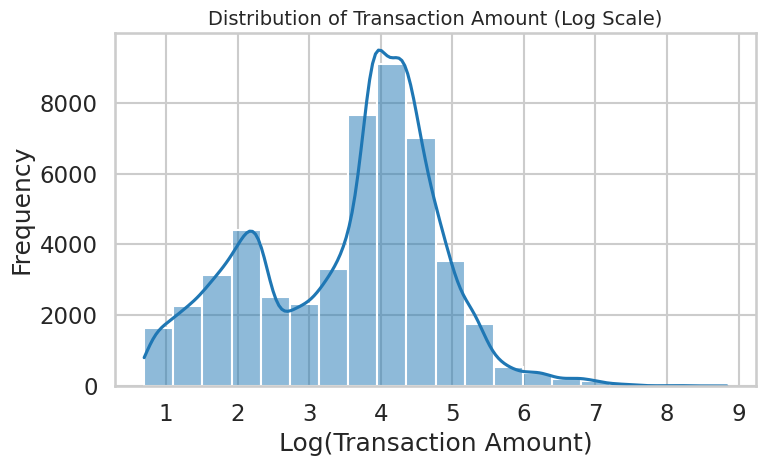

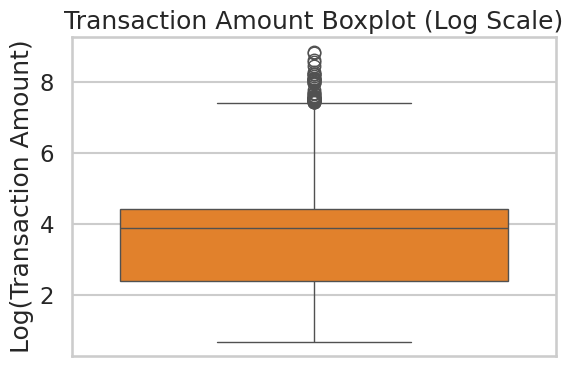

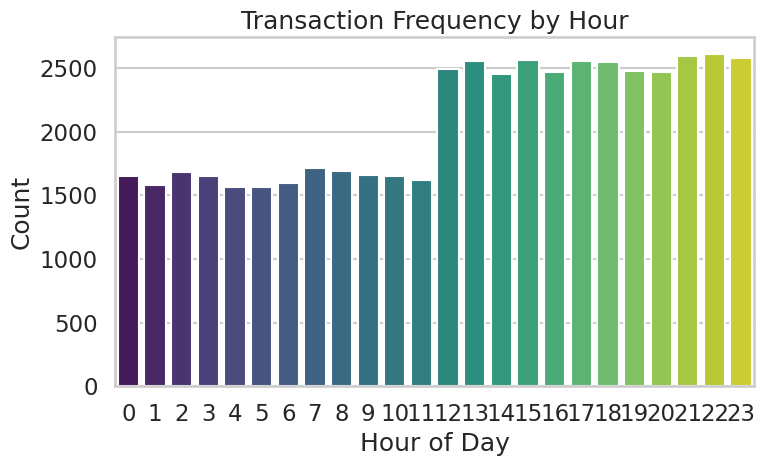


Bivariate Analysis


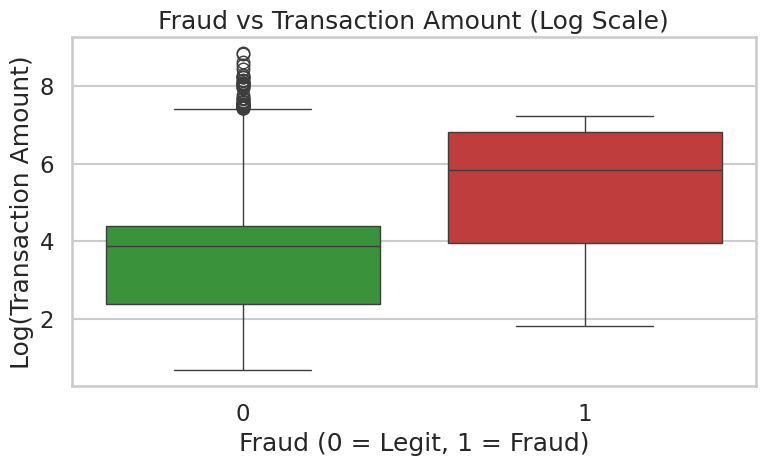

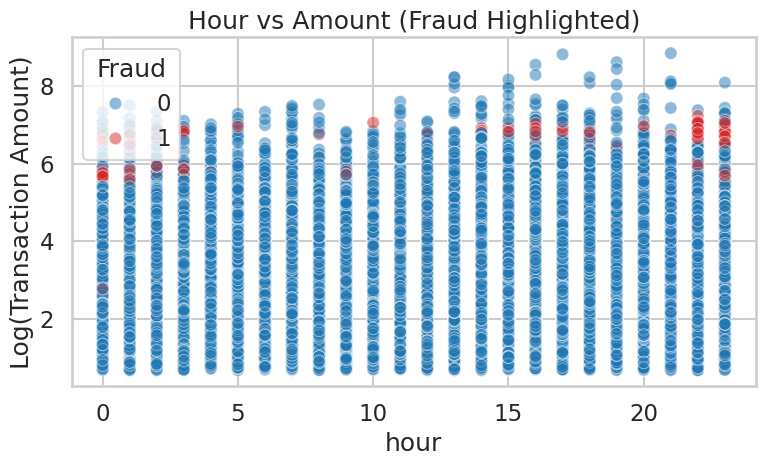


Multivariate Analysis


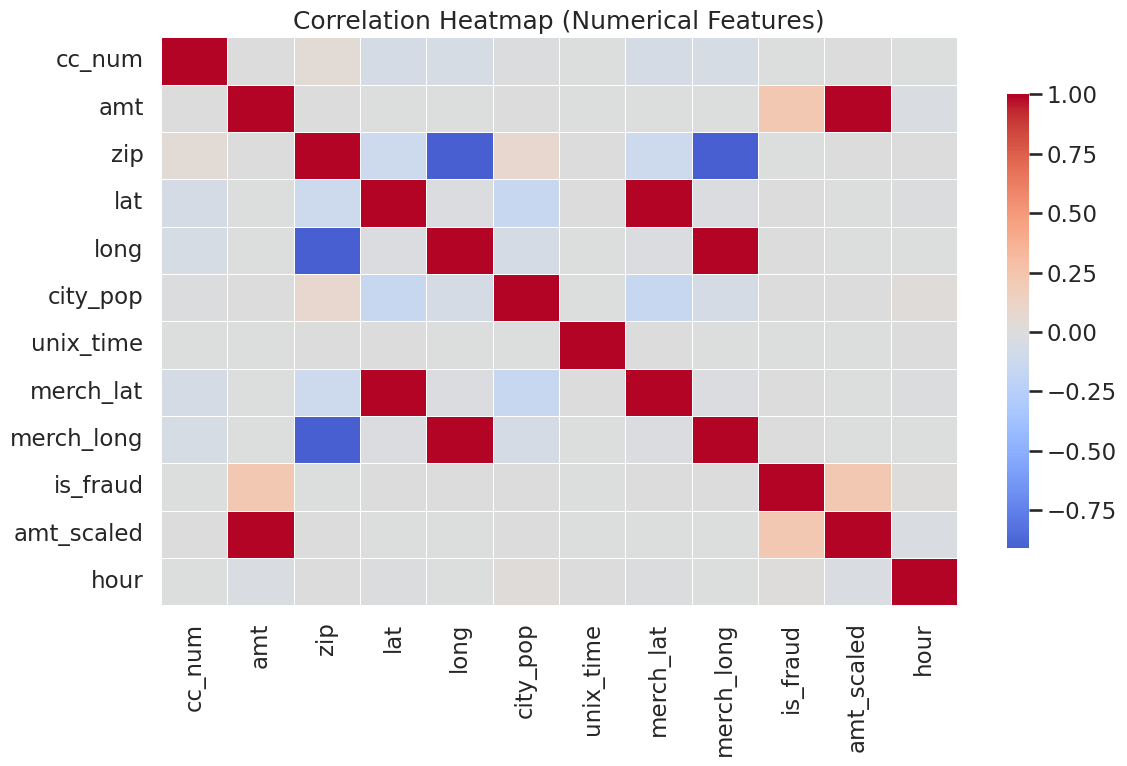

In [5]:
print("Week - 04")
#EDA DEEP DIVE

sns.set_style("whitegrid")
sns.set_context("talk")
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour
df_sample = df.sample(50000, random_state=42)

print("\nUnivariate Analysis")

#Histogram
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df_sample['amt']), bins=20, kde=True, color="#1f77b4")
plt.title("Distribution of Transaction Amount (Log Scale)", fontsize=14)
plt.xlabel("Log(Transaction Amount)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#Boxplot 
plt.figure(figsize=(6,4))
sns.boxplot(y=np.log1p(df_sample['amt']), color="#ff7f0e")
plt.title("Transaction Amount Boxplot (Log Scale)")
plt.ylabel("Log(Transaction Amount)")
plt.tight_layout()
plt.show()

#Countplot
plt.figure(figsize=(8,5))
sns.countplot(x='hour', data=df_sample, palette="viridis")
plt.title("Transaction Frequency by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("\nBivariate Analysis")

#Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x='is_fraud', y=np.log1p(df_sample['amt']),data=df_sample,palette=["#2ca02c", "#d62728"])
plt.title("Fraud vs Transaction Amount (Log Scale)")
plt.xlabel("Fraud (0 = Legit, 1 = Fraud)")
plt.ylabel("Log(Transaction Amount)")
plt.tight_layout()
plt.show()

#Scattter Plot
plt.figure(figsize=(8,5))
sns.scatterplot(x='hour', y=np.log1p(df_sample['amt']),hue='is_fraud',data=df_sample,alpha=0.5,palette={0: "#1f77b4", 1: "#d62728"})
plt.title("Hour vs Amount (Fraud Highlighted)")
plt.ylabel("Log(Transaction Amount)")
plt.legend(title="Fraud")
plt.tight_layout()
plt.show()

print("\nMultivariate Analysis")

#Heatmap
numeric_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(12,8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix,cmap="coolwarm",linewidths=0.5,center=0, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.show()
